# Week 06 — SpaceX First Stage Landing Prediction

This notebook collects SpaceX launch data, engineers features, performs EDA, trains ML models to predict **first stage landing success**, and generates artifacts (dataset, model, dashboard scaffold, report).

**Outputs**: `data/raw/*`, `data/processed_spacex.csv`, figures, `models/spacex_landing_model.joblib`, `src/dash_app.py`, `reports/final_report.md`.

Data source: SpaceX public API (v4/v5): https://github.com/r-spacex/SpaceX-API

## 1. Environment Setup

In [2]:
pip install plotly dash folium joblib xgboost

  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.8 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.8 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.8 MB 2.1 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.8 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.8 MB 2.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.8 MB 2.0 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.8 MB 2.0 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.8 MB 2.2 MB/s eta 0:00:03
   ----------------------- ---------------- 5.8/9.8 MB 2.4 MB/s eta 0:00:02
   ------------------------

In [3]:
# %pip install pandas numpy requests scikit-learn matplotlib seaborn plotly dash folium joblib xgboost
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False
import joblib, requests

BASE = Path().resolve()
DATA_DIR = BASE / "data"
RAW_DIR = DATA_DIR / "raw"
MODEL_DIR = BASE / "models"
SRC_DIR = BASE / "src"
REPORTS_DIR = BASE / "reports"
for d in [DATA_DIR, RAW_DIR, MODEL_DIR, SRC_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Ready.')


Ready.


## 2. Data Collection (SpaceX API)

In [4]:
SPACEX_BASE = "https://api.spacexdata.com/v4"
def fetch_and_save(endpoint):
    url = f"{SPACEX_BASE}/{endpoint}"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    data = r.json()
    (RAW_DIR / f"{endpoint.replace('/','_')}.json").write_text(json.dumps(data, indent=2), encoding="utf-8")
    return data

launches = fetch_and_save("launches")
rockets = fetch_and_save("rockets")
launchpads = fetch_and_save("launchpads")
payloads = fetch_and_save("payloads")
cores = fetch_and_save("cores")

len(launches), len(rockets), len(launchpads), len(payloads), len(cores)


(205, 4, 6, 225, 83)

### 2.1 Build lookups and normalize launches

In [5]:
def _lk(items):
    d = {}
    for it in items:
        _id = it.get("id") or it.get("_id")
        if _id: d[_id] = it
    return d

rocket_lk = _lk(rockets)
launchpad_lk = _lk(launchpads)
payload_lk = _lk(payloads)

def normalize(launches):
    rows = []
    for L in launches:
        name = L.get("name")
        date_utc = L.get("date_utc")
        flight_number = L.get("flight_number")
        rocket_id = L.get("rocket")
        pad_id = L.get("launchpad")
        payload_ids = L.get("payloads") or []
        cores = L.get("cores") or []

        rocket_name = rocket_lk.get(rocket_id, {}).get("name")
        pad = launchpad_lk.get(pad_id, {})
        launch_site = pad.get("name")
        pad_lat, pad_lon = pad.get("latitude"), pad.get("longitude")
        pad_locality = pad.get("locality")

        payload_mass = 0.0
        orbits = []
        customers = []
        for pid in payload_ids:
            p = payload_lk.get(pid, {})
            m = p.get("mass_kg")
            if m is not None: payload_mass += float(m)
            if p.get("orbit"): orbits.append(p.get("orbit"))
            if isinstance(p.get("customers"), list): customers += p.get("customers")

        landing_success = None
        landing_type = None
        if cores:
            c0 = cores[0]
            landing_success = c0.get("landing_success")
            landing_type = c0.get("landing_type")

        rows.append(dict(
            name=name,
            date_utc=date_utc,
            year=int(date_utc[:4]) if date_utc else None,
            month=int(date_utc[5:7]) if date_utc else None,
            flight_number=flight_number,
            rocket_name=rocket_name,
            launch_site=launch_site,
            pad_lat=pad_lat, pad_lon=pad_lon, pad_locality=pad_locality,
            payload_mass_kg=payload_mass if payload_mass else np.nan,
            orbit=orbits[0] if orbits else None,
            customers_count=len(set(customers)),
            num_payloads=len(payload_ids),
            landing_success=landing_success,
            landing_type=landing_type
        ))
    return pd.DataFrame(rows)

df = normalize(launches)
df.to_csv(DATA_DIR / "spacex_launches_summary.csv", index=False)
df.head()


,name,date_utc,year,month,flight_number,rocket_name,launch_site,pad_lat,pad_lon,pad_locality,payload_mass_kg,orbit,customers_count,num_payloads,landing_success,landing_type
0,FalconSat,2006-03-24T22:30:00.000Z,2006,3,1,Falcon 1,Kwajalein Atoll,9.047721,167.743129,Omelek Island,20.0,LEO,1,1,None,None
1,DemoSat,2007-03-21T01:10:00.000Z,2007,3,2,Falcon 1,Kwajalein Atoll,9.047721,167.743129,Omelek Island,NaN,LEO,1,1,None,None
2,Trailblazer,2008-08-03T03:34:00.000Z,2008,8,3,Falcon 1,Kwajalein Atoll,9.047721,167.743129,Omelek Island,NaN,LEO,2,2,None,None
3,RatSat,2008-09-28T23:15:00.000Z,2008,9,4,Falcon 1,Kwajalein Atoll,9.047721,167.743129,Omelek Island,165.0,LEO,1,1,None,None
4,RazakSat,2009-07-13T03:35:00.000Z,2009,7,5,Falcon 1,Kwajalein Atoll,9.047721,167.743129,Omelek Island,200.0,LEO,1,1,None,None


## 3. Feature Engineering & Cleaning

In [6]:
work = df.copy()
work = work[work['landing_success'].notnull()].copy()
work['landing_success'] = work['landing_success'].astype(int)

work['payload_mass_kg'] = work.groupby('orbit')['payload_mass_kg']    .transform(lambda s: s.fillna(s.median()))
work['payload_mass_kg'] = work['payload_mass_kg'].fillna(work['payload_mass_kg'].median())

num_cols = ['payload_mass_kg','flight_number','year','num_payloads','customers_count']
cat_cols = ['launch_site','orbit','rocket_name','landing_type']
label_col = 'landing_success'

model_df = work[num_cols + cat_cols + [label_col]].copy()
model_df.to_csv(DATA_DIR / "processed_spacex.csv", index=False)
model_df.sample(5, random_state=0)


,payload_mass_kg,flight_number,year,num_payloads,customers_count,launch_site,orbit,rocket_name,landing_type,landing_success
47,9600.0,48,2017,1,1,VAFB SLC 4E,PO,Falcon 9,ASDS,1
84,5000.0,85,2019,1,1,CCSFS SLC 40,ISS,Falcon 9,ASDS,1
65,9600.0,66,2018,1,1,VAFB SLC 4E,PO,Falcon 9,ASDS,1
143,13260.0,144,2022,1,1,KSC LC 39A,VLEO,Falcon 9,ASDS,1
45,475.0,46,2017,1,1,VAFB SLC 4E,SSO,Falcon 9,ASDS,1


## 4. EDA

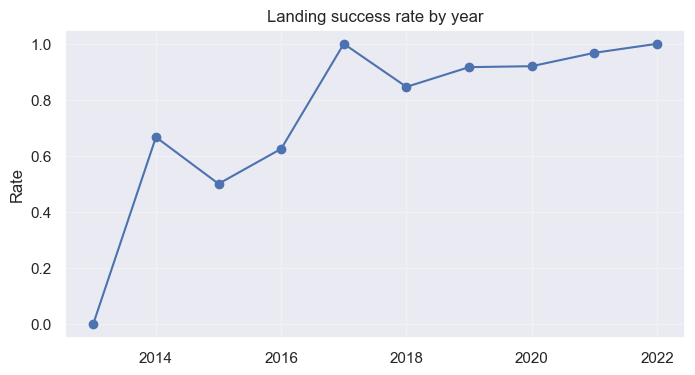

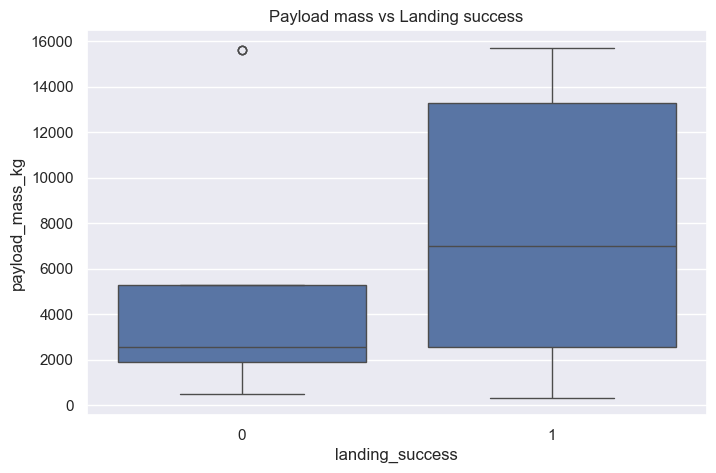

In [7]:
sns.set_theme()
rate = work.groupby('year')['landing_success'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(rate['year'], rate['landing_success'], marker='o')
ax.set_title("Landing success rate by year"); ax.set_ylabel("Rate"); ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=model_df, x='landing_success', y='payload_mass_kg', ax=ax)
ax.set_title("Payload mass vs Landing success"); plt.show()

fig = px.scatter(work, x='payload_mass_kg', y='flight_number', color='landing_success',
                 hover_data=['rocket_name','launch_site','orbit','year'],
                 title="Payload vs Flight Number")
fig.show()


## 5. Launchpads Map (Folium)

In [8]:
import folium
m = folium.Map(location=[28, -80], zoom_start=3)
pads = df[['launch_site','pad_lat','pad_lon','pad_locality']].dropna().drop_duplicates()
for _, r in pads.iterrows():
    folium.Marker([r['pad_lat'], r['pad_lon']], popup=f"{r['launch_site']} - {r['pad_locality']}").add_to(m)
map_path = REPORTS_DIR / "launchpads_map.html"
m.save(str(map_path))
map_path


WindowsPath('K:/downloads/reports/launchpads_map.html')

## 6. Modeling — Train/Test and Tuning

BASE RF
              precision    recall  f1-score   support

           0       0.20      0.33      0.25         3
           1       0.93      0.86      0.89        29

    accuracy                           0.81        32
   macro avg       0.56      0.60      0.57        32
weighted avg       0.86      0.81      0.83        32

ROC AUC: 0.764367816091954


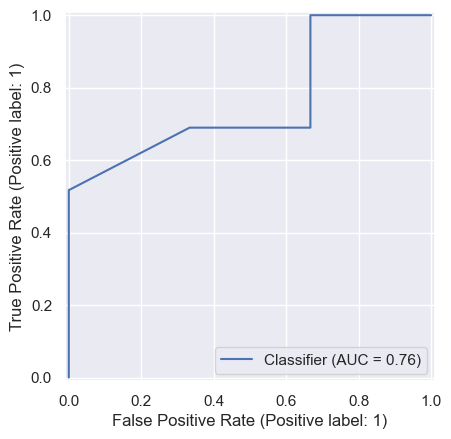

Fitting 5 folds for each of 12 candidates, totalling 60 fits
BEST RF
{'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.93      0.90      0.91        29

    accuracy                           0.84        32
   macro avg       0.59      0.61      0.60        32
weighted avg       0.86      0.84      0.85        32

ROC AUC: 0.8275862068965517


['K:\\downloads\\models\\spacex_landing_model.joblib']

In [11]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

X = model_df.drop(columns=[label_col])
y = model_df[label_col].astype(int)

cat_cols = [c for c in X.columns if c in ['launch_site','orbit','rocket_name','landing_type']]
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

base = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

base.fit(X_train, y_train)
pred = base.predict(X_test)
proba = base.predict_proba(X_test)[:,1]
print('BASE RF'); print(classification_report(y_test, pred)); print('ROC AUC:', roc_auc_score(y_test, proba))
RocCurveDisplay.from_predictions(y_test, proba); plt.show()

param_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 8, 16],
    'clf__min_samples_split': [2, 5]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(base, param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
best = gs.best_estimator_
pred = best.predict(X_test)
proba = best.predict_proba(X_test)[:,1]
print('BEST RF'); print(gs.best_params_); print(classification_report(y_test, pred)); print('ROC AUC:', roc_auc_score(y_test, proba))
joblib.dump(best, MODEL_DIR / "spacex_landing_model.joblib")


### XGBoost

In [ ]:
if HAVE_XGB:
    xgb_pipe = Pipeline([('pre', pre), ('clf', XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=42, eval_metric='logloss'
    ))])
    xgb_pipe.fit(X_train, y_train)
    pred = xgb_pipe.predict(X_test)
    proba = xgb_pipe.predict_proba(X_test)[:,1]
    print("XGB"); 
    print(classification_report(y_test, pred)); 
    print("ROC AUC:", roc_auc_score(y_test, proba))
    joblib.dump(xgb_pipe, MODEL_DIR / "spacex_landing_model_xgb.joblib")
else:
    print("XGBoost not installed.")

XGB
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.93      0.90      0.91        29

    accuracy                           0.84        32
   macro avg       0.59      0.61      0.60        32
weighted avg       0.86      0.84      0.85        32

ROC AUC: 0.8505747126436781


## 7. Feature Importance (RF)

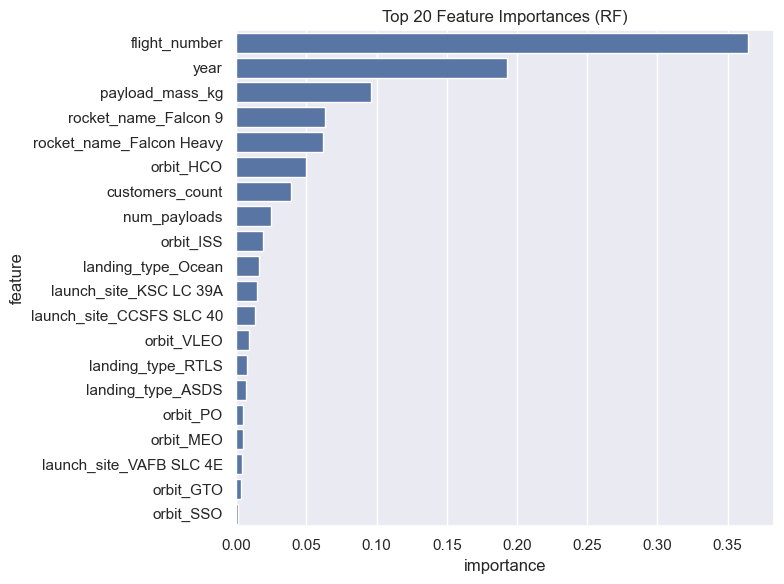

In [13]:
ohe = gs.best_estimator_.named_steps['pre'].named_transformers_['cat']
num_features = num_cols
cat_features = list(ohe.get_feature_names_out(cat_cols))
all_features = num_features + cat_features

rf = gs.best_estimator_.named_steps['clf']
imp = getattr(rf, "feature_importances_", None)
if imp is not None:
    importances = pd.DataFrame({'feature': all_features, 'importance': imp}).sort_values('importance', ascending=False).head(20)
    plt.figure(figsize=(8,6)); sns.barplot(data=importances, x='importance', y='feature'); plt.title("Top 20 Feature Importances (RF)"); plt.tight_layout(); plt.show()
    importances.head(10)
else:
    print("No feature_importances_ on classifier.")

## 8. Dashboard — Plotly Dash Scaffold

In [18]:
dash_code = '''
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd

df = pd.read_csv("data/processed_spacex.csv")

app = dash.Dash(__name__)
app.title = "SpaceX Landing Explorer"

app.layout = html.Div(children=[
    html.H2("SpaceX First Stage Landing — Explorer"),
    html.Div([
        html.Label("Launch Site"),
        dcc.Dropdown(id='site', options=[{'label': s, 'value': s} for s in sorted(df['launch_site'].dropna().unique())], value=None),
    ], style={'maxWidth':'420px'}),
    dcc.Graph(id="ts"),
    dcc.Graph(id="scatter"),
])

@app.callback(Output("ts","figure"), Input("site","value"))
def _ts(site):
    d = df if site is None else df[df['launch_site']==site]
    yearly = d.groupby("year")['landing_success'].mean().reset_index()
    fig = px.line(yearly, x="year", y="landing_success", title="Landing Success Rate by Year")
    return fig

@app.callback(Output("scatter","figure"), Input("site","value"))
def _sc(site):
    d = df if site is None else df[df['launch_site']==site]
    fig = px.scatter(d, x="payload_mass_kg", y="flight_number", color="landing_success",
                     hover_data=["rocket_name","orbit"], title="Payload vs Flight Number")
    return fig

if __name__ == "__main__":
    app.run(debug=True)
'''
(SRC_DIR / "dash_app.py").write_text(dash_code, encoding="utf-8")
print("Wrote:", SRC_DIR / "dash_app.py")

Wrote: K:\downloads\src\dash_app.py


## 9. How to Run


1. (Optional) Install requirements at the top.
2. Run Section 2 to fetch raw data (`data/raw`).
3. Run Section 3 to produce `data/processed_spacex.csv`.
4. Run Sections 4–7 for EDA and modeling; artifacts will be written to `models/`.
5. Start the dashboard locally with:
```bash
python src/dash_app.py
```
